# ERA5 three ways: pvlib, Arraylake and ECMWF ARCO, and IFS forecast verification for Madrid

This notebook ([#109](https://github.com/williamhobbs/hefty/issues/109)) uses ERA5 reanalysis as a reference for hefty day-ahead and 2-day-ahead IFS forecasts at a hypothetical solar plant near Madrid, Spain. It fetches the same ERA5 point time series in three ways and times each one:

1. **pvlib**: [`pvlib.iotools.get_era5`](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.iotools.get_era5.html) queries the CDS [ERA5 time-series](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries) API. You submit a job, wait in the queue, then download a CSV.
2. **Arraylake**: the free [`earthmover-public/era5`](https://app.earthmover.io/marketplace/6a19bcfe9aa6e97720a2fad2) Icechunk repo, group `single/temporal`, which is chunked for time series. It is updated quarterly and currently runs to 2026-03-31.
3. **ECMWF ARCO**: ECMWF's [Analysis-ready ERA5 single levels](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=analysis_ready_data) Zarr store, read from the `geoChunked` copy, which is chunked for time series. This is a beta service.

All three serve the same 0.25° ERA5 grid, so they should return identical values for the nearest grid cell. The comparison period is February 2026, which falls inside the free Arraylake product.

ERA5 is then used as ground truth to verify day-ahead and 2-day-ahead IFS forecasts hour by hour, using [climpred](https://climpred.readthedocs.io) and [xskillscore](https://xskillscore.readthedocs.io).

### Credentials
Put these in a `.env` file at the repository root. `.env` is already listed in `.gitignore`.
```
PRIVATE_CDSAPI_KEY=<your CDS personal access token>   # pvlib and ECMWF ARCO
ARRAYLAKE_TOKEN=<your Arraylake API token>            # Arraylake
```
You need to accept the ERA5 licence on the CDS website once before the CDS key will work.

### Extra dependencies
hefty does not depend on any of these packages, so install only the ones for the sources you want to use. Each cell below covers one source. After installing, restart the kernel.

**dynamical.org** (IFS forecast via hefty) and `python-dotenv` (to read `.env`):

In [ ]:
%pip install -q dynamical_catalog cartopy python-dotenv

**pvlib**: no extra packages needed, because `pvlib.iotools.get_era5` ships with pvlib, which hefty already depends on.

**Arraylake** (Icechunk repo, PCodec-compressed Zarr v3):

In [ ]:
%pip install -q arraylake icechunk xarray zarr "numcodecs[pcodec]"

**ECMWF ARCO** (Zarr v2 over HTTPS, read with obstore as ECMWF recommends):

In [ ]:
%pip install -q obstore xarray zarr

**Forecast verification** (climpred and xskillscore):

In [ ]:
%pip install -q climpred xskillscore

In [5]:
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
import xarray as xr
import climpred
import xskillscore as xs
from dotenv import find_dotenv, load_dotenv

from hefty.pv_model import model_pv_power
from hefty.solar import get_solar_forecast

warnings.simplefilter(action='ignore', category=FutureWarning)
load_dotenv(find_dotenv(usecwd=True));

## Site and period
The site is a hypothetical single-axis tracking plant just north of Madrid. The nearest ERA5 grid cell is 40.5°N, 3.75°W.

In [6]:
latitude, longitude = 40.42, -3.70  # Madrid, Spain

plant = dict(
    latitude=latitude,
    longitude=longitude,
    mount_type='single-axis',
    gcr=0.35,
    nameplate_dc=120,  # MW
    nameplate_ac=100,  # MW
    dc_loss_fraction=0.1,
    gamma_pdc=-0.003,
    shade_loss_model='non-linear_simple',
    backtrack=True,
    max_tracker_angle=55,
)

# February 2026 forecasts verified up to 72 h ahead, plus 2 days before for the persistence reference
start, end = '2026-01-30', '2026-03-03'  # inside the free Arraylake product (ends 2026-03-31)
year_start = '2025-03-04'                # 1-year window for the timing benchmark

## ERA5 fetchers
Each fetcher returns hourly `ghi` (W/m²), `temp_air` (°C) and `wind_speed` (m/s, at 10 m) for the nearest grid cell, using pvlib's conventions.

ERA5 radiation is accumulated over the hour **ending** at the timestamp. The `to_pvlib` helper converts J/m² to W/m² and shifts the index back 30 minutes to the interval centre, which matches the timestamps hefty uses for forecasts.

In [7]:
def to_pvlib(df):
    """ERA5 short names (ssrd, t2m, u10, v10) -> pvlib names/units, interval-centred UTC index."""
    out = pd.DataFrame(index=pd.DatetimeIndex(df.index))
    out['ghi'] = df['ssrd'] / 3600
    out['temp_air'] = df['t2m'] - 273.15
    out['wind_speed'] = np.hypot(df['u10'], df['v10'])
    if out.index.tz is None:
        out.index = out.index.tz_localize('UTC')
    out.index = out.index - pd.Timedelta('30min')
    return out.astype('float64')

ERA5_VARS = ['ssrd', 't2m', 'u10', 'v10']
# the CDS time-series API only accepts long names, but returns short-name columns
ERA5_LONG_NAMES = ['surface_solar_radiation_downwards', '2m_temperature',
                   '10m_u_component_of_wind', '10m_v_component_of_wind']

### 1. pvlib (CDS time-series API)

In [8]:
def era5_pvlib(start, end):
    df, meta = pvlib.iotools.get_era5(
        latitude, longitude, start, end, ERA5_LONG_NAMES,
        api_key=os.environ['PRIVATE_CDSAPI_KEY'],
        map_variables=False, timeout=600)
    return to_pvlib(df)

### 2. Arraylake (`earthmover-public/era5`, `single/temporal`)
Longitudes run from 0 to 360 and latitudes are descending.

In [9]:
def era5_arraylake(start, end):
    from arraylake import Client
    repo = Client(token=os.environ['ARRAYLAKE_TOKEN']).get_repo('earthmover-public/era5')
    session = repo.readonly_session(branch='main')
    ds = xr.open_zarr(session.store, group='single/temporal', zarr_format=3, chunks=None)
    pt = (ds[ERA5_VARS]
          .sel(latitude=latitude, longitude=longitude % 360, method='nearest')
          .sel(valid_time=slice(start, f'{end} 23:00')))
    return to_pvlib(pt.load().to_dataframe()[ERA5_VARS])

### 3. ECMWF ARCO (`geoChunked`)
The store uses Zarr v2 with consolidated metadata and requires the CDS key as a Bearer token. Longitudes run from -180 to 180 and latitudes are ascending.

In [10]:
ECMWF_ARCO_URL = ('https://arco.datastores.ecmwf.int/cadl-arco-geo-002/arco/'
                  'reanalysis_era5_single_levels/sfc/geoChunked.zarr')

def era5_ecmwf(start, end):
    from obstore.store import HTTPStore
    from zarr.storage import ObjectStore
    headers = {'Authorization': f"Bearer {os.environ['PRIVATE_CDSAPI_KEY']}"}
    store = ObjectStore(HTTPStore.from_url(ECMWF_ARCO_URL, client_options={'default_headers': headers}),
                        read_only=True)
    ds = xr.open_zarr(store, consolidated=True, zarr_format=2, chunks=None)
    pt = (ds[ERA5_VARS]
          .sel(latitude=latitude, longitude=longitude, method='nearest')
          .sel(time=slice(start, f'{end} 23:00')))
    return to_pvlib(pt.load().to_dataframe()[ERA5_VARS])

## Timing
Each method fetches the same 4 variables for one month and for one year. Every call is cold: opening the store or submitting the CDS request is counted in the time. Results depend heavily on where you run the notebook. Arraylake is hosted in AWS `us-east-1` and ECMWF ARCO is hosted in Europe. pvlib timings also depend on the CDS queue.

In [11]:
fetchers = {'pvlib': era5_pvlib, 'arraylake': era5_arraylake, 'ecmwf': era5_ecmwf}
windows = {'1 month': (start, end), '1 year': (year_start, end)}

era5, rows = {}, []
for method, fetch in fetchers.items():
    for window, (t0, t1) in windows.items():
        tic = time.perf_counter()
        df = fetch(t0, t1)
        elapsed = time.perf_counter() - tic
        rows.append(dict(method=method, window=window, seconds=elapsed, hours=len(df)))
        print(f'{method:>9} {window:>7}: {elapsed:6.1f} s, {len(df)} hours')
        if window == '1 month':
            era5[method] = df

timing = pd.DataFrame(rows).pivot(index='method', columns='window', values='seconds')
timing.round(1)

    pvlib 1 month:   20.1 s, 792 hours


    pvlib  1 year:   21.8 s, 8760 hours


arraylake 1 month:   23.5 s, 792 hours


arraylake  1 year:   32.6 s, 8760 hours


    ecmwf 1 month:    3.2 s, 792 hours


    ecmwf  1 year:    2.7 s, 8760 hours


window,1 month,1 year
method,,
arraylake,23.5,32.6
ecmwf,3.2,2.7
pvlib,20.1,21.8


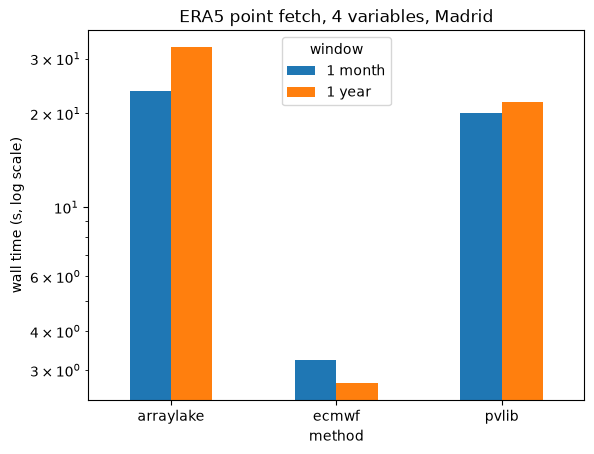

In [12]:
ax = timing.plot.bar(rot=0, logy=True)
ax.set_ylabel('wall time (s, log scale)')
ax.set_title('ERA5 point fetch, 4 variables, Madrid')
plt.show()

## Cross-check: are the three sources identical?
They should match. Each one is a lossless copy of the same ERA5 GRIB data, and pvlib's CSV uses rounded decimals.

In [13]:
diffs = pd.DataFrame({
    f'{a} - {b}': (era5[a] - era5[b]).abs().max()
    for a, b in [('arraylake', 'ecmwf'), ('arraylake', 'pvlib'), ('ecmwf', 'pvlib')]
})
diffs  # max absolute difference per variable

,arraylake - ecmwf,arraylake - pvlib,ecmwf - pvlib
ghi,0.000000,0.000030,2.983941e-05
temp_air,0.000000,0.000021,2.124023e-05
wind_speed,0.000012,0.000012,4.447508e-07


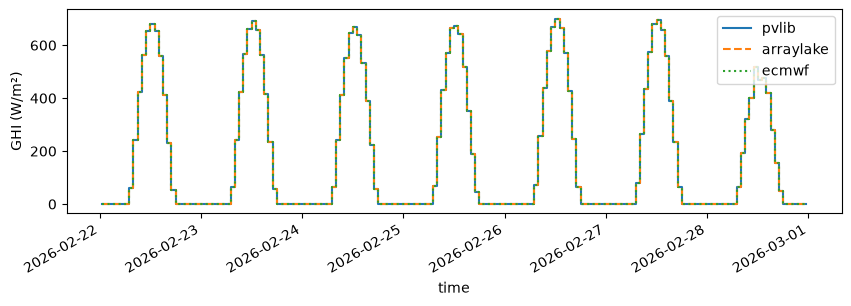

In [14]:
fig, ax = plt.subplots(figsize=(10, 3))
for (method, df), ls in zip(era5.items(), ['-', '--', ':']):
    df['ghi']['2026-02-22':'2026-02-28'].plot(ax=ax, ls=ls, label=method, drawstyle='steps-mid')
ax.set_ylabel('GHI (W/m²)')
ax.legend()
plt.show()

## Day-ahead and 2-day-ahead IFS forecasts, first week of February 2026
This section uses hefty's IFS forecast from dynamical.org (see [dynamical_example.ipynb](dynamical_example.ipynb)). Each forecast is initialized at 00Z on one day between 1 and 7 February 2026 and is kept hourly from 25 to 72 hours of lead time:

- **lead day 1**: leads of 25 to 48 hours, i.e. the next calendar day
- **lead day 2**: leads of 49 to 72 hours, i.e. the day after that

Each dynamical call takes about 45 s, so 7 initializations take about 5 minutes. Extend `init_dates` to cover the whole month if you like, which takes about 20 minutes. Every forecast is cached as a CSV under `~/data/hefty_era5_example/`, which makes reruns instant.

In [15]:
init_dates = pd.date_range('2026-02-01', '2026-02-07', freq='1D')  # 00Z initializations

cache_dir = Path.home() / 'data' / 'hefty_era5_example'
cache_dir.mkdir(parents=True, exist_ok=True)

def get_ifs_cached(init_date):
    path = cache_dir / f'ifs_dynamical_{init_date:%Y%m%d%H}_{latitude}_{longitude}.csv'
    if path.exists():
        return pd.read_csv(path, index_col=0, parse_dates=True)
    df = get_solar_forecast(
        latitude=latitude, longitude=longitude, init_date=init_date,
        run_length=48, lead_time_to_start=24,
        model='ifs', attempts=3, priority='dynamical')
    df.to_csv(path)
    return df

fcasts = {init: get_ifs_cached(init) for init in init_dates}
fcasts[init_dates[0]].head()

,point,temp_air,wind_speed,wind_direction,lead_time,ghi_csi,ghi,dni,dhi,ghi_clear
valid_time,,,,,,,,,,
2026-02-02 00:30:00+00:00,0,7.036459,1.306730,83.06611,24.5,0.0,0.0,0.0,0.0,NaN
2026-02-02 01:30:00+00:00,0,7.546875,2.845524,129.41140,25.5,0.0,0.0,0.0,0.0,NaN
2026-02-02 02:30:00+00:00,0,8.057292,4.384319,175.75670,26.5,0.0,0.0,0.0,0.0,NaN
2026-02-02 03:30:00+00:00,0,8.177083,4.649047,194.11662,27.5,0.0,0.0,0.0,0.0,NaN
2026-02-02 04:30:00+00:00,0,7.906250,3.639710,184.49118,28.5,0.0,0.0,0.0,0.0,NaN


### PV power and putting the data on an `init` × `lead` grid
The hourly PV power for each forecast and for ERA5 comes from `model_pv_power`. ERA5 provides only GHI, so DNI and DHI are estimated with the Erbs decomposition, as hefty does for forecasts by default. Albedo is set to 0.2 for both.

For verification, all timestamps are moved to the **end** of each hourly interval, matching ERA5's native convention. A forecast value at `init + lead` hours is then compared with the ERA5 value at that same time. This is the layout climpred expects: forecasts with `init` and `lead` dimensions, and observations with a `time` dimension.

In [16]:
def add_decomposition(df):
    df = df.copy()
    sp = pvlib.solarposition.get_solarposition(df.index, latitude, longitude)
    erbs = pvlib.irradiance.erbs(df['ghi'], sp['zenith'], df.index)
    df['dni'], df['dhi'] = erbs['dni'], erbs['dhi']
    return df

def pv_power(resource):
    resource = resource.copy()
    resource['albedo'] = 0.2
    return model_pv_power(resource_data=resource, **plant)[0]

def to_interval_end(df):
    return df.set_axis((df.index + pd.Timedelta('30min')).tz_convert(None))

# ground truth: ERA5 from Arraylake (identical to the other two sources, see above)
era5_resource = add_decomposition(era5['arraylake'])
obs_df = to_interval_end(pd.DataFrame({'ghi': era5_resource['ghi'], 'power': pv_power(era5_resource)}))
obs = obs_df.rename_axis('time').to_xarray()

# forecasts on an init x lead grid
rows = []
for init, f in fcasts.items():
    f = f.copy()
    f['power'] = pv_power(f)
    f = to_interval_end(f)
    f['init'] = init
    f['lead'] = ((f.index - init) / pd.Timedelta('1h')).astype(int)
    rows.append(f.rename_axis('valid_time').reset_index())
fc_long = pd.concat(rows, ignore_index=True)
fc_long['lead_day'] = np.ceil(fc_long['lead'] / 24).astype(int) - 1

fc = fc_long.set_index(['init', 'lead'])[['ghi', 'power']].to_xarray()
fc.lead.attrs['units'] = 'hours'
fc

<xarray.Dataset> Size: 6kB
Dimensions:  (init: 7, lead: 48)
Coordinates:
  * init     (init) datetime64[us] 56B 2026-02-01 2026-02-02 ... 2026-02-07
  * lead     (lead) int64 384B 25 26 27 28 29 30 31 32 ... 66 67 68 69 70 71 72
Data variables:
    ghi      (init, lead) float64 3kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    power    (init, lead) float64 3kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

### Reference forecast: diurnal persistence
climpred's built-in `persistence` reference would repeat the 00Z value at every lead, and 00Z is night here. Instead, the reference forecast takes the ERA5 value at the same hour of day on the last full day before initialization. That is 48 hours earlier for lead day 1 and 72 hours earlier for lead day 2. This reference is a little optimistic, because in practice ERA5 is only available about 5 days late.

In [17]:
hour = np.timedelta64(1, 'h')
valid_time = fc.init + fc.lead * hour
shift = 24 * np.ceil(fc.lead / 24) * hour  # 48 h for lead day 1, 72 h for lead day 2
persistence = obs.sel(time=valid_time - shift).drop_vars('time')
persistence.lead.attrs['units'] = 'hours'

### Time series: ERA5 vs lead day 1 and lead day 2

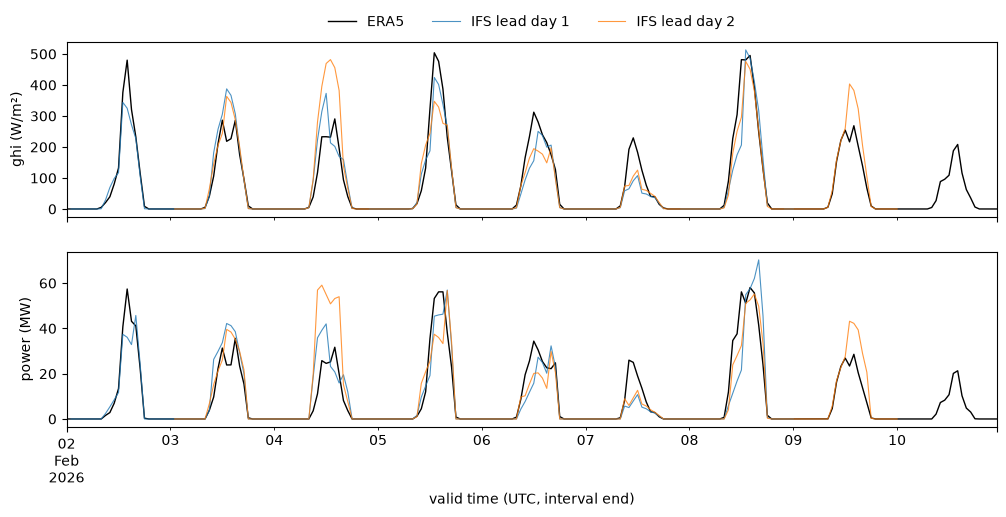

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, var, unit in zip(axes, ['ghi', 'power'], ['W/m²', 'MW']):
    obs_df[var]['2026-02-02':'2026-02-10'].plot(ax=ax, color='black', lw=1, label='ERA5')
    for day, color in [(1, 'tab:blue'), (2, 'tab:orange')]:
        s = fc_long[fc_long['lead_day'] == day].set_index('valid_time')[var]
        s.plot(ax=ax, color=color, lw=0.8, alpha=0.8, label=f'IFS lead day {day}')
    ax.set_ylabel(f'{var} ({unit})')
axes[0].legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.0), frameon=False)
axes[1].set_xlabel('valid time (UTC, interval end)')
plt.show()

### Skill by lead hour with climpred
`HindcastEnsemble.verify` lines up each forecast `init + lead` with the observation at that valid time and computes the metric over all 7 initializations, giving one value per lead hour. With `alignment='same_inits'`, every lead hour is scored on the same set of initializations.

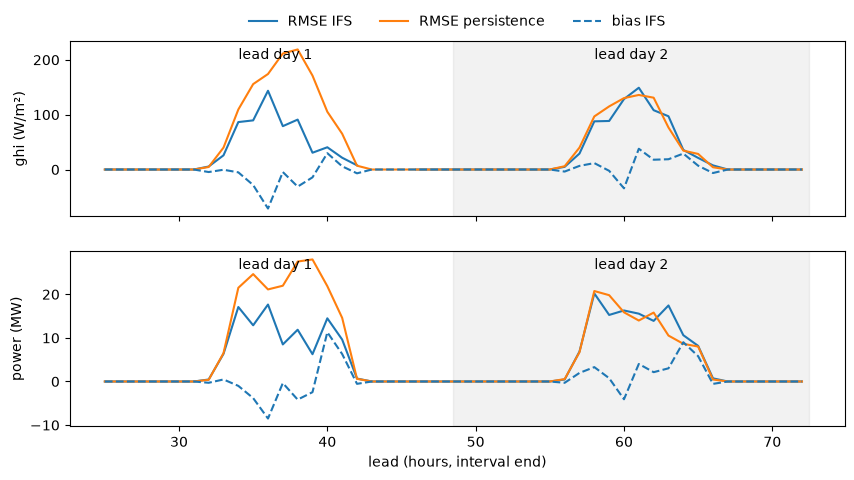

In [19]:
def verify(initialized, metric):
    return (climpred.HindcastEnsemble(initialized)
            .add_observations(obs)
            .verify(metric=metric, comparison='e2o', dim='init', alignment='same_inits'))

rmse = xr.concat([verify(fc, 'rmse'), verify(persistence, 'rmse')],
                 dim=pd.Index(['IFS', 'persistence'], name='forecast'))
bias = verify(fc, 'bias')  # forecast - ERA5

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, var, unit in zip(axes, ['ghi', 'power'], ['W/m²', 'MW']):
    for name in rmse.forecast.values:
        rmse[var].sel(forecast=name).plot(ax=ax, label=f'RMSE {name}')
    bias[var].plot(ax=ax, ls='--', color='tab:blue', label='bias IFS')
    ax.axvspan(48.5, 72.5, color='grey', alpha=0.1)
    ax.set_title('')
    ax.set_xlabel('')
    ax.set_ylabel(f'{var} ({unit})')
    for x, label in [(36.5, 'lead day 1'), (60.5, 'lead day 2')]:
        ax.text(x, 0.9, label, ha='center', transform=ax.get_xaxis_transform())
axes[0].legend(ncol=3, loc='lower center', bbox_to_anchor=(0.5, 1.0), frameon=False)
axes[1].set_xlabel('lead (hours, interval end)')
plt.show()

### Summary by lead day with xskillscore
For each lead day, the metrics below are computed with xskillscore across all initializations and all **daytime** hours, defined as hours where ERA5 GHI > 0. Night hours are excluded because they would inflate the correlation and shrink the errors. The RMSE skill score compares IFS with diurnal persistence: 1 is perfect, and anything above 0 beats persistence.

In [20]:
verif = obs.sel(time=valid_time).drop_vars('time')  # ERA5 on the init x lead grid
lead_day = np.ceil(fc.lead / 24).astype(int) - 1
daytime = verif['ghi'] > 0

rows = []
for day in (1, 2):
    leads = fc.lead[lead_day == day]
    for var in ['ghi', 'power']:
        o = verif[var].sel(lead=leads).where(daytime.sel(lead=leads))
        row = dict(lead_day=day, variable=var)
        for name, f in [('IFS', fc), ('persistence', persistence)]:
            f = f[var].sel(lead=leads).where(o.notnull())
            kw = dict(dim=['init', 'lead'], skipna=True)
            row[f'{name} MBE'] = float(xs.me(f, o, **kw))
            row[f'{name} MAE'] = float(xs.mae(f, o, **kw))
            row[f'{name} RMSE'] = float(xs.rmse(f, o, **kw))
            row[f'{name} r'] = float(xs.pearson_r(f, o, **kw))
        row['RMSE skill score'] = 1 - row['IFS RMSE'] / row['persistence RMSE']
        rows.append(row)

summary = pd.DataFrame(rows).set_index(['variable', 'lead_day'])
summary.round(2)

,,IFS MBE,IFS MAE,IFS RMSE,IFS r,persistence MBE,persistence MAE,persistence RMSE,persistence r,RMSE skill score
variable,lead_day,,,,,,,,,
ghi,1,-11.92,46.73,70.36,0.88,-2.15,94.79,136.70,0.53,0.49
power,1,-0.28,7.66,11.14,0.81,-0.03,13.92,19.71,0.39,0.43
ghi,2,7.46,56.07,84.23,0.81,0.73,57.23,87.74,0.80,0.04
power,2,2.28,8.91,13.05,0.73,0.81,8.38,12.85,0.73,-0.02


Daily energy is what a day-ahead market cares about most. Summing PV power over each lead day gives one value per initialization and lead day:

In [21]:
fc_energy = fc['power'].groupby(lead_day.rename('lead_day')).sum()        # MWh per day
obs_energy = verif['power'].groupby(lead_day.rename('lead_day')).sum()
pers_energy = persistence['power'].groupby(lead_day.rename('lead_day')).sum()

energy = pd.DataFrame({
    'ERA5 mean (MWh/day)': obs_energy.mean('init').to_series(),
    'IFS MBE (MWh/day)': xs.me(fc_energy, obs_energy, dim='init').to_series(),
    'IFS MAE (MWh/day)': xs.mae(fc_energy, obs_energy, dim='init').to_series(),
    'IFS MAPE (%)': 100 * xs.mape(fc_energy, obs_energy, dim='init').to_series(),
    'persistence MAE (MWh/day)': xs.mae(pers_energy, obs_energy, dim='init').to_series(),
})
energy.round(1)

,ERA5 mean (MWh/day),IFS MBE (MWh/day),IFS MAE (MWh/day),IFS MAPE (%),persistence MAE (MWh/day)
lead_day,,,,,
1,221.2,-3.0,45.4,34.8,120.8
2,212.0,25.1,73.3,36.1,79.4


-----
_This document/data/output/Results is/are based on data and products of the European Centre for Medium-Range Weather Forecasts (ECMWF). © 2026 European Centre for Medium-Range Weather Forecasts (ECMWF), www.ecmwf.int. This data is published under a Creative Commons Attribution 4.0 International (CC BY 4.0). https://creativecommons.org/licenses/by/4.0/_

_Contains modified Copernicus Climate Change Service information 2026 (ERA5, Hersbach et al., 2023, doi:10.24381/cds.adbb2d47). Neither the European Commission nor ECMWF is responsible for any use that may be made of the Copernicus information or data it contains._